This shows multiple ways to invoke mutiple LLM model providers.
1. Using langchain init_chat_model
2. Using the langchain LLM Provider libraries e.g. langchain_opennai

In [ ]:
from dotenv import load_dotenv
import os
import langchain

load_dotenv(override=True)
API_HOST = os.getenv("API_HOST", "github")
langchain.__version__

'1.2.0'

Using Open AI

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama


if API_HOST == "github":
    print("Using GitHub Hosted Infra and LLM model:", os.getenv("GITHUB_MODEL", "openai/gpt-4o"))
    llm = ChatOpenAI(
        model_name=os.getenv("GITHUB_MODEL", "openai/gpt-4o"),
        openai_api_base="https://models.github.ai/inference",
        openai_api_key=os.environ["GITHUB_TOKEN"],
    )
elif API_HOST == "ollama":
    print("Using Ollama model on local...")
    llm = ChatOllama(model=os.getenv("OLLAMA_MODEL", "mistral"))

Using GitHub Hosted Infra and LLM model: gpt-4o-mini


In [36]:
#Define the functions i.e. tools

def get_weather(city:str)->str:
    """Gets the weather of the city""" ## --> very important Doc String to help the LLM decide
    return f"The weather of the {city} is sunny"



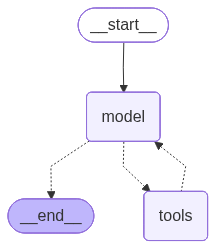

In [37]:
# Create the agent

from langchain.agents import create_agent

agent = create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt="you are an helpul assistant",
)
agent

In [38]:
# Run the agent
response = agent.invoke({
                        "messages":
                                {"role": "user", "content":"what is the weather in Pune"}
                         }
)
response['messages'][-1].content

'The weather in Pune is currently sunny.'

Integration with OpenAI hosted on GitHub

In [39]:
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage

llm = init_chat_model(
                        model=os.getenv("GITHUB_MODEL", "openai/gpt-4o"),
                        openai_api_base="https://models.github.ai/inference",
                        openai_api_key=os.environ["GITHUB_TOKEN"]
                        )

response = llm.invoke([
    HumanMessage(content="Say hello in one sentence")
])
response

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 12, 'total_tokens': 22, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f97eff32c5', 'id': 'chatcmpl-Ct78nVSe2TfILp1lr9ff0qqJmcQcP', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019b7866-3f02-7803-9188-b58a96a2f2b8-0', usage_metadata={'input_tokens': 12, 'output_tokens': 10, 'total_tokens': 22, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

Integration with Google Gemini

In [ ]:
# Google Gemini model. This requires langchain-google-genai package
from langchain.chat_models import init_chat_model

llm = init_chat_model(
                        model="gemini-2.5-flash-lite",
                        model_provider="google_genai",
                        google_api_key=os.getenv("GOOGLE_API_KEY")
                    )
response = llm.invoke("why do parrots talk")
response.content

'Parrots talk for a fascinating combination of **evolutionary adaptation, cognitive abilities, and social needs**. It\'s not a single, simple reason, but rather a complex interplay of factors.\n\nHere\'s a breakdown of why parrots talk:\n\n**1. Social Bonding and Communication:**\n\n*   **Flock Animals:** Parrots are highly social creatures that live in flocks. In the wild, effective communication is crucial for survival. They need to warn each other of predators, locate food sources, maintain contact with the group, and strengthen social bonds within the flock.\n*   **Mimicry as a Tool:** Mimicry is a powerful tool for social integration. By imitating the calls and sounds of their flock mates, parrots can:\n    *   **Identify themselves:** Help others recognize them.\n    *   **Maintain flock cohesion:** Stay in contact when foraging or when visibility is poor.\n    *   **Signal their status:** Certain vocalizations might indicate dominance or submission.\n    *   **Learn and adapt:**

In [41]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", google_api_key=os.getenv("GOOGLE_API_KEY"))
response = llm.invoke("why do parrots talk")
response.content

'Parrots talk for a fascinating combination of **instinct, social learning, and their remarkable cognitive abilities.** It\'s not simply "mimicry" in the way a tape recorder works; there\'s a lot more going on.\n\nHere\'s a breakdown of the main reasons why parrots talk:\n\n**1. Social Bonding and Communication:**\n\n*   **Highly Social Creatures:** Parrots are intensely social animals in the wild. They live in flocks and rely on vocalizations for a wide range of communication, including:\n    *   **Maintaining flock cohesion:** Letting others know their location, warning of danger, and coordinating movement.\n    *   **Establishing dominance and hierarchy:** Vocalizations can play a role in social pecking orders.\n    *   **Courtship and mating rituals:** Specific calls and songs are used to attract mates and reinforce pair bonds.\n    *   **Sharing information:** They might signal the location of food or water sources.\n*   **Mimicry as a Social Tool:** In their natural environment, 